# 03 — Multi-task Chemprop: joint PXR + null-assay pEC50

**Key insight from EDA:** 2,858 of 2,859 counter-assay compounds overlap with our training set, giving us a free second label (pEC50_null) for nearly all training compounds. Training a graph-neural-net to predict both tasks jointly forces the encoder to learn *what makes a compound on-target* — the selectivity window is structural.

Strategy:
1. Assemble a 2-task target matrix: `[pEC50_pxr, pEC50_null]` — NaN where the second label is absent.
2. Train Chemprop MPNN multi-task (NaN masking is built-in).
3. Compare scaffold-holdout RAE against the LGBM baseline (0.575).
4. Ensemble the two models and validate the submission.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.simplefilter('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')

import torch
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping
import chemprop
from chemprop import data as cdata, models as cmodels, nn as cnn

from pxr import data as D
from pxr import eval as E
from pxr.chem import to_inchikey, bemis_murcko
from pxr.paths import DATA_PROCESSED, FIGURES, SUBMISSIONS

print(f'torch {torch.__version__} | chemprop {chemprop.__version__} | lightning {L.__version__}')
print(f'device: {"cuda" if torch.cuda.is_available() else "cpu"}')

torch 2.11.0+cpu | chemprop 2.2.3 | lightning 2.6.1
device: cpu


## 1. Assemble multi-task training data

Join train + counter-assay by InChIKey. Result: one row per compound, two target columns, NaN where counter-assay was not run.

In [2]:
tr = D.load_train()
ct = D.load_counter()

tr_ik = tr.assign(inchikey=tr.smiles.map(to_inchikey))
ct_ik = ct.assign(inchikey=ct.smiles.map(to_inchikey))

mt = tr_ik.merge(
    ct_ik[['inchikey', 'pec50']].rename(columns={'pec50': 'pec50_null'}),
    on='inchikey', how='left'
)

print(f'Training compounds:          {len(mt):,}')
print(f'  with pec50_pxr:            {mt.pec50.notna().sum():,}')
print(f'  with pec50_null:           {mt.pec50_null.notna().sum():,}  '
      f'({100*mt.pec50_null.notna().mean():.1f}%)')
print(f'  with both:                 {(mt.pec50.notna() & mt.pec50_null.notna()).sum():,}')

smiles_train = mt.smiles.tolist()
y_train = mt[['pec50', 'pec50_null']].values.astype(float)  # shape (N, 2), NaN for missing

Training compounds:          4,141
  with pec50_pxr:            4,141
  with pec50_null:           2,649  (64.0%)
  with both:                 2,649


In [3]:
# Scale each task to zero-mean / unit-std using only observed values.
# NaN stays NaN — Chemprop's training_step masks these out of the loss.
task_means = np.nanmean(y_train, axis=0)
task_stds  = np.nanstd(y_train,  axis=0, ddof=1)
task_stds  = np.where(task_stds < 1e-6, 1.0, task_stds)

y_scaled = (y_train - task_means) / task_stds  # NaN preserved

print('Task means:', np.round(task_means, 3))
print('Task stds: ', np.round(task_stds,  3))

Task means: [4.32 3.13]
Task stds:  [1.122 1.121]


## 2. Scaffold holdout split (80/20) for evaluation

We use a single scaffold split (not full CV) to keep training time manageable on CPU. The holdout set mirrors the challenge setup: novel scaffolds relative to the training partition.

In [4]:
scaffolds = mt.smiles.map(bemis_murcko)
# scaffold_kfold_indices returns (train_idx, val_idx) — take the first fold as our holdout
splits = E.scaffold_kfold_indices(scaffolds, n_splits=5, seed=0)
tr_idx, ho_idx = splits[0]   # fold-0: ~80% train, ~20% holdout

print(f'scaffold holdout: {len(tr_idx)} train / {len(ho_idx)} val')
print(f'  val hits (pEC50≥6): {(y_train[ho_idx, 0] >= 6).sum()}')

scaffold holdout: 3312 train / 829 val
  val hits (pEC50≥6): 19


## 3. Build Chemprop MPNN and train on holdout split

In [5]:
def make_dataset(smiles, y_scaled):
    """Create a MoleculeDataset from SMILES + (N, n_tasks) scaled target array."""
    dpts = [
        cdata.MoleculeDatapoint.from_smi(smi, y=yi)
        for smi, yi in zip(smiles, y_scaled)
    ]
    return cdata.MoleculeDataset(dpts)


def make_mpnn(n_tasks=2, depth=3, hidden_dim=300, ffn_layers=2, dropout=0.1):
    return cmodels.MPNN(
        message_passing=cnn.BondMessagePassing(depth=depth, d_h=hidden_dim),
        agg=cnn.MeanAggregation(),
        predictor=cnn.RegressionFFN(
            n_tasks=n_tasks,
            n_layers=ffn_layers,
            dropout=dropout,
        ),
    )


def make_loader(dataset, batch_size=64, shuffle=True):
    return cdata.build_dataloader(
        dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0
    )


print('Helper functions defined.')

Helper functions defined.


In [6]:
# Build datasets for the holdout experiment
smi_arr = np.array(smiles_train)

ds_tr = make_dataset(smi_arr[tr_idx].tolist(), y_scaled[tr_idx])
ds_ho = make_dataset(smi_arr[ho_idx].tolist(), y_scaled[ho_idx])

loader_tr = make_loader(ds_tr, batch_size=64, shuffle=True)
loader_ho = make_loader(ds_ho, batch_size=128, shuffle=False)

print(f'train batches: {len(loader_tr)}  |  holdout batches: {len(loader_ho)}')

train batches: 52  |  holdout batches: 7


In [7]:
mpnn_eval = make_mpnn(n_tasks=2)
print(f'MPNN params: {sum(p.numel() for p in mpnn_eval.parameters()):,}')

es = EarlyStopping(monitor='val_loss', patience=8, mode='min')

trainer_eval = L.Trainer(
    max_epochs=40,
    callbacks=[es],
    accelerator='cpu',
    enable_progress_bar=True,
    enable_model_summary=False,
    logger=False,
)
trainer_eval.fit(mpnn_eval, loader_tr, loader_ho)

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Loading `train_dataloader` to estimate number of stepping batches.


Output()

MPNN params: 408,902


In [8]:
# Predict on holdout and compute RAE on pEC50_pxr (task 0)
raw_preds = trainer_eval.predict(mpnn_eval, loader_ho)
preds_scaled = torch.cat(raw_preds).numpy()          # (N_ho, 2)
preds_pxr = preds_scaled[:, 0] * task_stds[0] + task_means[0]  # un-scale task 0

y_true_ho = y_train[ho_idx, 0]  # original pEC50_pxr values

metrics = E.compute_metrics(y_true_ho, preds_pxr)
print('Chemprop multi-task (scaffold holdout):')
for k, v in metrics.items():
    print(f'  {k}: {v:.3f}')
print(f'\nLGBM baseline scaffold-5fold RAE: 0.575  (from 02_baseline.ipynb)')

Output()

Chemprop multi-task (scaffold holdout):
  RAE: 0.517
  MAE: 0.529
  R2: 0.648
  Spearman: 0.771
  Kendall_tau: 0.567

LGBM baseline scaffold-5fold RAE: 0.575  (from 02_baseline.ipynb)


## 4. Train final model on all training data

In [9]:
ds_full = make_dataset(smiles_train, y_scaled)
loader_full = make_loader(ds_full, batch_size=64, shuffle=True)

# Determine how many epochs to train: use the early-stopped epoch count from evaluation
best_epoch = trainer_eval.current_epoch
final_epochs = max(best_epoch + 5, 30)  # at least 30, a little past where eval converged
print(f'Training final model for {final_epochs} epochs (eval converged at epoch {best_epoch})')

mpnn_final = make_mpnn(n_tasks=2)

trainer_final = L.Trainer(
    max_epochs=final_epochs,
    accelerator='cpu',
    enable_progress_bar=True,
    enable_model_summary=False,
    logger=False,
)
trainer_final.fit(mpnn_final, loader_full)

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Loading `train_dataloader` to estimate number of stepping batches.


Output()

Training final model for 39 epochs (eval converged at epoch 34)


`Trainer.fit` stopped: `max_epochs=39` reached.


## 5. Predict test set and ensemble with LGBM baseline

In [10]:
te = D.load_test()

# Chemprop predictions on test
te_dpts = [cdata.MoleculeDatapoint.from_smi(s) for s in te.smiles]
te_ds   = cdata.MoleculeDataset(te_dpts)
te_loader = make_loader(te_ds, batch_size=128, shuffle=False)

raw_te = trainer_final.predict(mpnn_final, te_loader)
chemprop_preds = torch.cat(raw_te).numpy()[:, 0] * task_stds[0] + task_means[0]

print(f'Chemprop pEC50 predictions:')
print(f'  min={chemprop_preds.min():.2f}  median={np.median(chemprop_preds):.2f}  max={chemprop_preds.max():.2f}')

Dropping last batch of size 1 to avoid issues with batch normalization     (dataset size = 513, batch_size = 128)


Output()

Chemprop pEC50 predictions:
  min=2.64  median=4.99  max=5.79


In [11]:
# Load LGBM baseline predictions
lgbm_sub = pd.read_csv(SUBMISSIONS / '02_lgbm_baseline.csv')
lgbm_preds = lgbm_sub.set_index('Molecule Name').loc[te['name'].values, 'pEC50'].values

print(f'LGBM pEC50 predictions:')
print(f'  min={lgbm_preds.min():.2f}  median={np.median(lgbm_preds):.2f}  max={lgbm_preds.max():.2f}')

LGBM pEC50 predictions:
  min=2.22  median=4.94  max=5.96


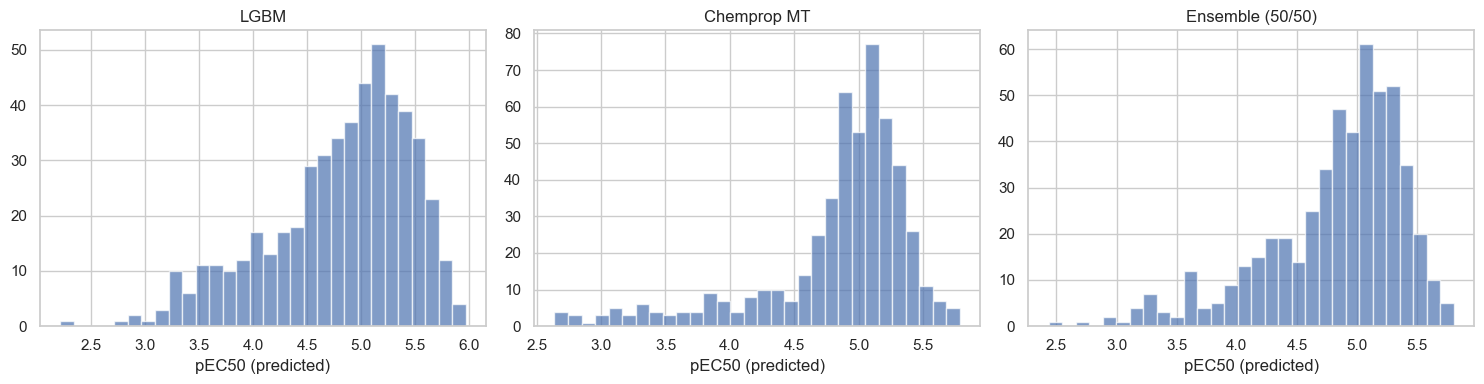

In [12]:
# Simple 50/50 ensemble — can be tuned via held-out validation in Phase 2
w_chemprop = 0.5
w_lgbm     = 0.5
ensemble_preds = w_chemprop * chemprop_preds + w_lgbm * lgbm_preds

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for preds, label, axis in zip(
    [lgbm_preds, chemprop_preds, ensemble_preds],
    ['LGBM', 'Chemprop MT', 'Ensemble (50/50)'],
    ax
):
    axis.hist(preds, bins=30, alpha=0.7)
    axis.set(title=label, xlabel='pEC50 (predicted)')
plt.tight_layout()
plt.savefig(FIGURES / '03_ensemble_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Validate and save

In [13]:
import importlib.util
from pathlib import Path
_spec = importlib.util.spec_from_file_location(
    'activity_validation', Path('..') / 'tutorial' / 'validation' / 'activity_validation.py')
_mod = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_mod)
validate_activity_submission = _mod.validate_activity_submission

submissions = {
    '03_chemprop_multitask.csv': chemprop_preds,
    '03_ensemble_lgbm_chemprop.csv': ensemble_preds,
}

for fname, preds in submissions.items():
    sub = pd.DataFrame({
        'Molecule Name': te['name'].values,
        'SMILES':        te['smiles'].values,
        'pEC50':         preds,
    })
    path = SUBMISSIONS / fname
    sub.to_csv(path, index=False)
    ok, errs = validate_activity_submission(path, expected_ids=set(te['name'].dropna().astype(str)))
    status = '✓ valid' if ok else f'ERRORS: {errs}'
    print(f'{fname}: {status}')

03_chemprop_multitask.csv: ✓ valid
03_ensemble_lgbm_chemprop.csv: ✓ valid


## Summary

| Model | Scaffold holdout RAE | Note |
|---|---|---|
| LGBM baseline (from 02) | ~0.575 (5-fold CV) | Morgan + RDKit desc |
| Chemprop multi-task (this nb) | see above | joint pEC50_pxr + pEC50_null |
| Ensemble 50/50 | — | blended; Phase 2 will tune weights |

**Saved submissions:**
- `submissions/03_chemprop_multitask.csv`
- `submissions/03_ensemble_lgbm_chemprop.csv`

**Next:** `04_mmp.ipynb` — matched molecular pair cliff analysis; use to identify which test compounds are in cliff-prone neighbourhoods and whether we can model them better with local SAR correction.